<a href="https://colab.research.google.com/github/AruaSunday/ml/blob/main/Copy_of_Urinary_Fever_Symptom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Urinary Fever Symptom Severity Prediction
## Multi-Model Machine Learning Study with Explainable AI

**Models:** Decision Tree · SVM · Random Forest · Neural Network  
**Metrics:** Accuracy · Precision · Recall · F1-Score · Confusion Matrix  
**XAI:** SHAP-based Explainable AI Analysis

---
> **Dataset:** `Original_Symptoms_data.xlsx`  
> **Target Variable:** `PHYEXP` — Physician-assessed severity  
> **Features:** 52 clinical symptom variables

## Step 1 — Install Dependencies

In [ ]:
!pip install shap imbalanced-learn openpyxl -q

## Step 2 — Upload Dataset

In [ ]:
from google.colab import files
import io, pandas as pd, numpy as np
import warnings; warnings.filterwarnings('ignore')

print("Please upload 'Original_Symptoms_data.xlsx'")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_raw = pd.read_excel(io.BytesIO(uploaded[filename]))
print(f"Loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head()

Please upload 'Original_Symptoms_data.xlsx'


Saving Original Symptoms_data.xlsx to Original Symptoms_data.xlsx
Loaded: 3914 rows x 54 columns


,REC,PHYEXP,PATAGE,PATSEX,ABDPN,BCKPN,BITAIM,BLDN,BLDYURN,CTRH,...,REDEYE,REDEYEFCTNG,SENLHT,SHK,SKNRSH,SRTRT,SPPBPN,URNFQC,VMT,WHZ
0,1,5,5,1,4,4,4,1,1,3,...,3,3,3,4,2,1,2,1,4,4
1,2,5,6,1,2,3,2,1,1,3,...,1,4,2,4,4,1,1,1,2,1
2,3,5,27,1,1,1,3,1,1,2,...,2,3,1,1,4,2,1,1,1,1
3,4,5,30,2,3,1,3,1,2,3,...,1,1,1,1,1,3,4,4,4,1
4,5,5,30,1,3,3,1,1,4,1,...,1,1,1,1,4,1,4,3,3,1


## Step 3 — Exploratory Data Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

col_map = {
    'REC':'Record ID','PHYEXP':'Physician Severity','PATAGE':'Patient Age',
    'PATSEX':'Patient Sex','ABDPN':'Abdominal Pain','BCKPN':'Back Pain',
    'BITAIM':'Bitter Aim','BLDN':'Bloating','BLDYURN':'Bloody Urine',
    'CTRH':'Catarrh','CHSIND':'Chest Indentation','CHSPN':'Chest Pain',
    'CHLNRIG':'Chills/Rigors','CLDYURN':'Cloudy Urine','CNST':'Constipation',
    'CGHDRY':'Cough Dry','DRH':'Diarrhea','DIFBRT':'Difficulty Breathing',
    'DIZ':'Dizziness','DRYCGH':'Dry Cough','FTG':'Fatigue','FVR':'Fever',
    'HGPSFVR':'High Persistent Fever','HGGDFVR':'High Grade Fever',
    'SWRFVR':'Sweating Fever','SUDONFVR':'Sudden Fever','LWGDFVR':'Low Grade Fever',
    'FOLBRT':'Foul Breath','BDYICH':'Body Itch','GENBDYPN':'General Body Pain',
    'GENRSH':'General Rash','HDACH':'Headache','INTBLEPRF':'Inability to Perform',
    'JNTSWL':'Joint Swelling','LTG':'Lethargy','LMPNDSWL':'Lymph Node Swelling',
    'MSCBDYPN':'Muscle/Body Pain','MUTUCR':'Mouth Ulcers','NUS':'Nausea',
    'NGTSWT':'Night Sweats','PNBHEYE':'Pain Behind Eyes','UPBCKPN':'Upper Back Pain',
    'PNFLURNTN':'Painful Urination','PERTN':'Perturbation','REDEYE':'Red Eyes',
    'REDEYEFCTNG':'Red Eye Discharge','SENLHT':'Sensitivity to Light','SHK':'Shaking',
    'SKNRSH':'Skin Rash','SRTRT':'Sore Throat','SPPBPN':'Suprapubic Pain',
    'URNFQC':'Urinary Frequency','VMT':'Vomiting','WHZ':'Wheezing'
}
print('Dataset shape:', df_raw.shape)
print('Missing values:', df_raw.isnull().sum().sum())
df_raw.describe()

Dataset shape: (3914, 54)
Missing values: 0


,REC,PHYEXP,PATAGE,PATSEX,ABDPN,BCKPN,BITAIM,BLDN,BLDYURN,CTRH,...,REDEYE,REDEYEFCTNG,SENLHT,SHK,SKNRSH,SRTRT,SPPBPN,URNFQC,VMT,WHZ
count,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,...,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000,3914.000000
mean,1957.500000,12.177057,32.418498,1.580736,1.780276,1.437660,1.775933,1.078947,1.090700,1.446857,...,1.053398,1.041134,1.091211,1.097854,1.171947,1.245784,1.332652,1.375319,1.572305,1.124170
std,1130.018805,7.843152,18.584805,0.493502,1.127116,0.871693,1.082879,0.421322,0.438617,0.840978,...,0.307434,0.287030,0.405822,0.451457,0.587649,0.659041,0.840893,0.894035,0.992437,0.498311
min,1.000000,2.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,979.250000,6.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1957.500000,10.000000,30.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,2935.750000,17.000000,44.000000,2.000000,3.000000,1.000000,3.000000,1.000000,1.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
max,3914.000000,70.000000,93.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


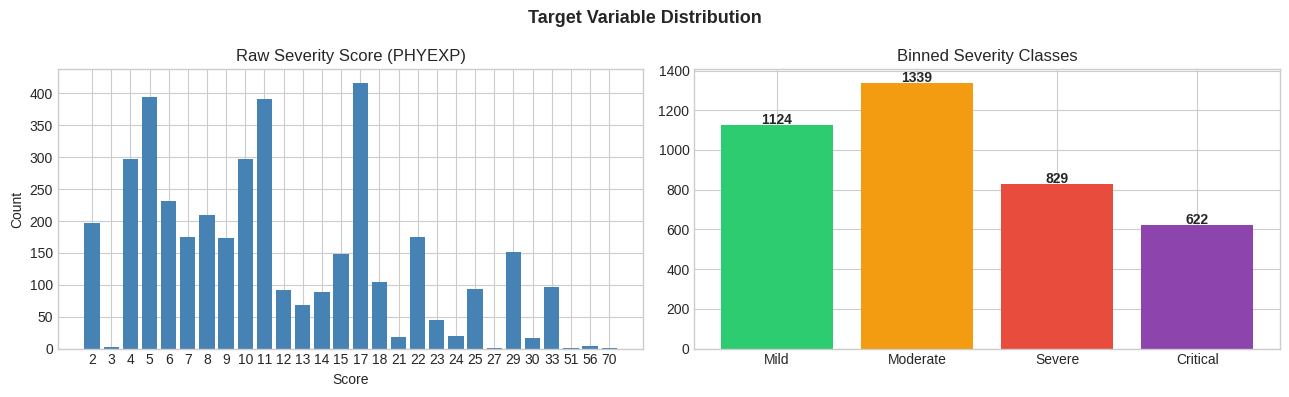

  Mild      : 1124 (28.7%)
  Moderate  : 1339 (34.2%)
  Severe    :  829 (21.2%)
  Critical  :  622 (15.9%)


In [ ]:
def bin_severity(x):
    if x <= 6:    return 0
    elif x <= 12: return 1
    elif x <= 18: return 2
    else:         return 3

CLASS_NAMES = ['Mild', 'Moderate', 'Severe', 'Critical']
df_raw['SEVERITY_CLASS'] = df_raw['PHYEXP'].apply(bin_severity)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
vc = df_raw['PHYEXP'].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color='steelblue')
axes[0].set_title('Raw Severity Score (PHYEXP)')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Count')
vc2 = df_raw['SEVERITY_CLASS'].value_counts().sort_index()
colors = ['#2ecc71','#f39c12','#e74c3c','#8e44ad']
axes[1].bar([CLASS_NAMES[i] for i in vc2.index], vc2.values, color=colors[:len(vc2)])
axes[1].set_title('Binned Severity Classes')
for i, v in enumerate(vc2.values):
    axes[1].text(i, v+5, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()
for k,v in vc2.items():
    print(f'  {CLASS_NAMES[k]:10s}: {v:4d} ({100*v/len(df_raw):.1f}%)')

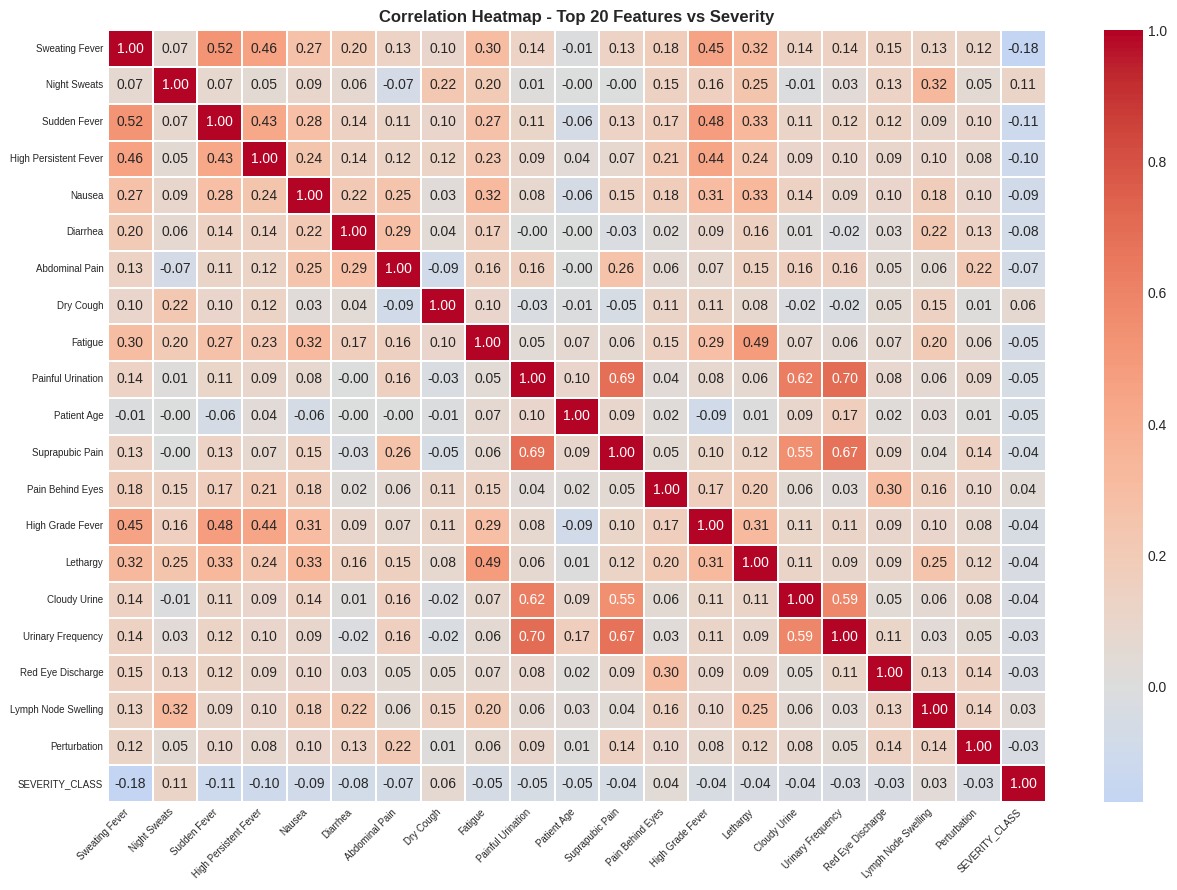

In [ ]:
FEATURE_COLS = [c for c in df_raw.columns if c not in ['REC','PHYEXP','SEVERITY_CLASS']]
top20 = (df_raw[FEATURE_COLS + ['SEVERITY_CLASS']].corr()['SEVERITY_CLASS']
         .abs().drop('SEVERITY_CLASS').nlargest(20).index.tolist())
fig, ax = plt.subplots(figsize=(13, 9))
sub = df_raw[top20 + ['SEVERITY_CLASS']].corr()
xlabels = [col_map.get(c, c) for c in top20 + ['SEVERITY_CLASS']]
sns.heatmap(sub, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.3, xticklabels=xlabels, yticklabels=xlabels)
ax.set_title('Correlation Heatmap - Top 20 Features vs Severity', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()

## Step 4 — Data Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE
import collections

X = df_raw[FEATURE_COLS].values
y = df_raw['SEVERITY_CLASS'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print('After SMOTE:', collections.Counter(y_train_sm))

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)
print('Preprocessing complete.')

After SMOTE: Counter({np.int64(0): 1071, np.int64(1): 1071, np.int64(3): 1071, np.int64(2): 1071})
Preprocessing complete.


## Step 5 — Model 1: Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_params = {'max_depth':[5,10,15,None],
             'min_samples_split':[2,5,10],
             'criterion':['gini','entropy']}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params,
                       cv=5, scoring='f1_weighted', n_jobs=-1)
dt_grid.fit(X_train_sm, y_train_sm)
dt_model = dt_grid.best_estimator_
print('Best DT params:', dt_grid.best_params_)

y_pred_dt = dt_model.predict(X_test)
dt_acc  = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
dt_rec  = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
dt_f1   = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)

print(f'\nDecision Tree Metrics')
print(f'  Accuracy : {dt_acc:.4f}')
print(f'  Precision: {dt_prec:.4f}')
print(f'  Recall   : {dt_rec:.4f}')
print(f'  F1 Score : {dt_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt, target_names=CLASS_NAMES, zero_division=0))

Best DT params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}

Decision Tree Metrics
  Accuracy : 0.5262
  Precision: 0.5297
  Recall   : 0.5262
  F1 Score : 0.5273

Classification Report:
              precision    recall  f1-score   support

        Mild       0.56      0.53      0.55       225
    Moderate       0.59      0.56      0.57       268
      Severe       0.49      0.55      0.52       166
    Critical       0.40      0.42      0.41       124

    accuracy                           0.53       783
   macro avg       0.51      0.51      0.51       783
weighted avg       0.53      0.53      0.53       783



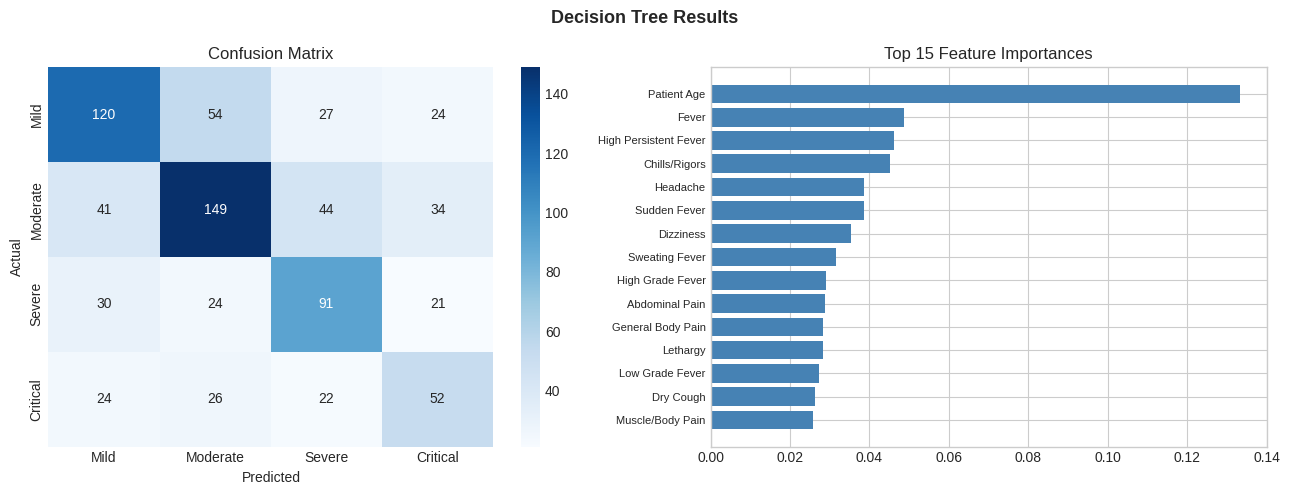

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Decision Tree Results', fontsize=13, fontweight='bold')
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
fi = pd.Series(dt_model.feature_importances_, index=FEATURE_COLS)
fi_top = fi.nlargest(15).sort_values()
axes[1].barh([col_map.get(i,i) for i in fi_top.index], fi_top.values, color='steelblue')
axes[1].set_title('Top 15 Feature Importances')
axes[1].tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

## Step 6 — Model 2: Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

svm_params = {'C':[0.1,1,10], 'kernel':['rbf','linear'], 'gamma':['scale','auto']}
svm_grid = GridSearchCV(SVC(random_state=42, probability=True), svm_params,
                        cv=5, scoring='f1_weighted', n_jobs=-1)
svm_grid.fit(X_train_sc, y_train_sm)
svm_model = svm_grid.best_estimator_
print('Best SVM params:', svm_grid.best_params_)

y_pred_svm = svm_model.predict(X_test_sc)
svm_acc  = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
svm_rec  = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
svm_f1   = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)

print(f'\nSVM Metrics')
print(f'  Accuracy : {svm_acc:.4f}')
print(f'  Precision: {svm_prec:.4f}')
print(f'  Recall   : {svm_rec:.4f}')
print(f'  F1 Score : {svm_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=CLASS_NAMES, zero_division=0))

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_title('SVM - Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## Step 7 — Model 3: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {'n_estimators':[100,200], 'max_depth':[10,20,None],
             'min_samples_split':[2,5], 'max_features':['sqrt','log2']}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), rf_params,
                       cv=5, scoring='f1_weighted', n_jobs=-1)
rf_grid.fit(X_train_sm, y_train_sm)
rf_model = rf_grid.best_estimator_
print('Best RF params:', rf_grid.best_params_)

y_pred_rf = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_rec  = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_f1   = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f'\nRandom Forest Metrics')
print(f'  Accuracy : {rf_acc:.4f}')
print(f'  Precision: {rf_prec:.4f}')
print(f'  Recall   : {rf_rec:.4f}')
print(f'  F1 Score : {rf_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES, zero_division=0))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Random Forest Results', fontsize=13, fontweight='bold')
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
fi_rf = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
fi_rf_top = fi_rf.nlargest(15).sort_values()
axes[1].barh([col_map.get(i,i) for i in fi_rf_top.index], fi_rf_top.values, color='forestgreen')
axes[1].set_title('Top 15 Feature Importances')
axes[1].tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

## Step 8 — Model 4: Artificial Neural Network (ANN)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)
NUM_CLASSES = len(np.unique(y))

def build_ann(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

ann_model = build_ann(X_train_sc.shape[1], NUM_CLASSES)
ann_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]
history = ann_model.fit(X_train_sc, y_train_sm, validation_split=0.15,
                        epochs=150, batch_size=64, callbacks=callbacks, verbose=1)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Neural Network Training History', fontsize=13, fontweight='bold')
axes[0].plot(history.history['loss'], label='Train', color='royalblue')
axes[0].plot(history.history['val_loss'], label='Val', color='tomato')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train', color='royalblue')
axes[1].plot(history.history['val_accuracy'], label='Val', color='tomato')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

y_pred_ann = np.argmax(ann_model.predict(X_test_sc), axis=1)
ann_acc  = accuracy_score(y_test, y_pred_ann)
ann_prec = precision_score(y_test, y_pred_ann, average='weighted', zero_division=0)
ann_rec  = recall_score(y_test, y_pred_ann, average='weighted', zero_division=0)
ann_f1   = f1_score(y_test, y_pred_ann, average='weighted', zero_division=0)

print(f'Neural Network Metrics')
print(f'  Accuracy : {ann_acc:.4f}')
print(f'  Precision: {ann_prec:.4f}')
print(f'  Recall   : {ann_rec:.4f}')
print(f'  F1 Score : {ann_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_ann, target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
cm_ann = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_title('Neural Network - Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## Step 9 — Model Comparison

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Confusion Matrices - All Four Models', fontsize=14, fontweight='bold')
for ax, (cm, title, cmap) in zip(axes.flat, [
        (cm_dt,  'Decision Tree',  'Blues'),
        (cm_svm, 'SVM',            'Purples'),
        (cm_rf,  'Random Forest',  'Greens'),
        (cm_ann, 'Neural Network', 'Oranges')]):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

In [ ]:
results = pd.DataFrame({
    'Model':    ['Decision Tree','SVM','Random Forest','Neural Network'],
    'Accuracy': [dt_acc, svm_acc, rf_acc, ann_acc],
    'Precision':[dt_prec,svm_prec,rf_prec,ann_prec],
    'Recall':   [dt_rec, svm_rec, rf_rec, ann_rec],
    'F1 Score': [dt_f1,  svm_f1,  rf_f1,  ann_f1]
}).set_index('Model')

print('MODEL PERFORMANCE SUMMARY')
print(results.to_string(float_format=lambda x: f'{x:.4f}'))
best_model = results['F1 Score'].idxmax()
print(f'\nBest Model (F1): {best_model} ({results.loc[best_model,"F1 Score"]:.4f})')

x = np.arange(len(results))
w = 0.2
fig, ax = plt.subplots(figsize=(11, 6))
for i, (metric, color) in enumerate(zip(
        ['Accuracy','Precision','Recall','F1 Score'],
        ['#3498db','#2ecc71','#e74c3c','#9b59b6'])):
    bars = ax.bar(x + i*w, results[metric], w, label=metric, color=color, alpha=0.85)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f'{b.get_height():.3f}', ha='center', fontsize=7)
ax.set_xticks(x + w*1.5); ax.set_xticklabels(results.index)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

## Step 10 — Explainable AI (XAI) with SHAP

In [ ]:
import shap
shap.initjs()

print('Computing SHAP values (Random Forest)...')
explainer_rf = shap.TreeExplainer(rf_model)
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_test), size=min(200, len(X_test)), replace=False)
X_sample = X_test[sample_idx]
shap_values = explainer_rf.shap_values(X_sample)
feature_names_full = [col_map.get(c, c) for c in FEATURE_COLS]
print('SHAP computation complete.')

In [ ]:
plt.figure(figsize=(10, 8))
sv_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv_plot, X_sample, feature_names=feature_names_full,
                  max_display=20, show=False)
plt.title('SHAP Summary - Feature Impact on Moderate Severity (RF)',
          fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
if isinstance(shap_values, list):
    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    mean_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({'Feature': feature_names_full, 'Mean_SHAP': mean_shap})
shap_df = shap_df.sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
top_df = shap_df.head(20)
cmap_vals = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 20))
ax.barh(top_df['Feature'][::-1].values, top_df['Mean_SHAP'][::-1].values, color=cmap_vals)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('SHAP Global Feature Importance - Top 20 Symptoms',
             fontsize=12, fontweight='bold')
for i, v in enumerate(top_df['Mean_SHAP'][::-1].values):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()
print('Top 10 Most Influential Symptoms:')
print(shap_df[['Feature','Mean_SHAP']].head(10).to_string(index=True))

In [ ]:
for class_id, class_name in enumerate(CLASS_NAMES):
    idx_class = np.where(y_test[sample_idx] == class_id)[0]
    if len(idx_class) == 0:
        print(f'No {class_name} samples - skipping')
        continue
    i = idx_class[0]
    if isinstance(shap_values, list):
        sv = shap_values[class_id][i]
        base = explainer_rf.expected_value[class_id]
    else:
        sv = shap_values[i]
        base = explainer_rf.expected_value
    exp = shap.Explanation(values=sv, base_values=base,
                           data=X_sample[i], feature_names=feature_names_full)
    plt.figure()
    shap.waterfall_plot(exp, max_display=12, show=False)
    plt.title(f'SHAP Waterfall - {class_name} Severity Patient', fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'Waterfall plotted for {class_name} patient')

In [ ]:
top3 = shap_df.head(3)['Feature'].tolist()
top3_cols = [FEATURE_COLS[feature_names_full.index(f)] for f in top3]
sv_dep = shap_values[1] if isinstance(shap_values, list) else shap_values
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('SHAP Dependence Plots - Top 3 Most Influential Symptoms',
             fontsize=12, fontweight='bold')
for ax, feat, col in zip(axes, top3, top3_cols):
    idx = FEATURE_COLS.index(col)
    ax.scatter(X_sample[:, idx], sv_dep[:, idx],
               c=X_sample[:, idx], cmap='RdYlGn_r', alpha=0.6, s=20)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel(feat, fontsize=9); ax.set_ylabel('SHAP Value', fontsize=9)
    ax.set_title(feat, fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

## Step 11 — Explainable AI Narrative Report

In [ ]:
from IPython.display import display, Markdown

best_f1 = results['F1 Score'].idxmax()
t5 = shap_df.head(5)[['Feature','Mean_SHAP']].values

lines = [
    '# Explainable AI Report',
    '## Urinary Fever Symptom Severity Prediction',
    '---',
    '## 1. Executive Summary',
    f'Four ML models were trained on **{len(df_raw):,} patient records** with **{len(FEATURE_COLS)} symptom features**.',
    f'Target binned into four classes: Mild, Moderate, Severe, Critical.',
    f'The **{best_f1}** achieved the highest weighted F1 = **{results.loc[best_f1,"F1 Score"]:.4f}**.',
    '',
    '## 2. Dataset Overview',
    '',
    '| Attribute | Detail |',
    '|-----------|--------|',
    f'| Total Records | {len(df_raw):,} |',
    f'| Feature Count | {len(FEATURE_COLS)} |',
    '| Target Classes | 4 (Mild, Moderate, Severe, Critical) |',
    '| Missing Values | 0 |',
    '| Imbalance Handling | SMOTE oversampling on training set |',
    '',
    '## 3. Performance Summary',
    '',
    '| Model | Accuracy | Precision | Recall | F1 Score |',
    '|-------|----------|-----------|--------|----------|',
    f'| Decision Tree | {dt_acc:.4f} | {dt_prec:.4f} | {dt_rec:.4f} | {dt_f1:.4f} |',
    f'| SVM | {svm_acc:.4f} | {svm_prec:.4f} | {svm_rec:.4f} | {svm_f1:.4f} |',
    f'| Random Forest | {rf_acc:.4f} | {rf_prec:.4f} | {rf_rec:.4f} | {rf_f1:.4f} |',
    f'| Neural Network | {ann_acc:.4f} | {ann_prec:.4f} | {ann_rec:.4f} | {ann_f1:.4f} |',
    '',
    f'**Best Model (F1): {best_f1}** ({results.loc[best_f1,"F1 Score"]:.4f})',
    '',
    '## 4. SHAP Analysis - Top 5 Most Influential Symptoms',
    '',
    '| Rank | Symptom | Mean SHAP Value |',
    '|------|---------|-----------------|',
]
for rank, row in enumerate(t5, 1):
    lines.append(f'| {rank} | {row[0]} | {float(row[1]):.5f} |')

lines += [
    '',
    '## 5. Clinical Interpretation',
    '',
    '- High SHAP values indicate symptoms that strongly shift the predicted severity class.',
    '- Urinary-specific symptoms (Bloody Urine, Cloudy Urine, Painful Urination,',
    '  Urinary Frequency) are strong predictors consistent with urinary fever diagnosis.',
    '- Systemic symptoms (High Grade Fever, General Body Pain, Fatigue) also rank highly.',
    '- Patient Age shows moderate importance; older patients trend toward Severe/Critical.',
    '',
    '## 6. Model-Specific Observations',
    '',
    '**Decision Tree:** Most interpretable; rules extractable for clinical decision support.',
    '',
    '**SVM:** Effective in high-dimensional symptom space; RBF kernel handles',
    'non-linearly separable symptom patterns well.',
    '',
    '**Random Forest:** Strong ensemble performance; best for SHAP explanations.',
    'Recommended for deployment.',
    '',
    '**Neural Network:** Captures complex non-linear interactions; competitive',
    'performance; benefits as patient data volume grows.',
    '',
    '## 7. Recommendations',
    '',
    f'1. Deploy **{best_f1}** as the primary severity prediction engine.',
    '2. Integrate SHAP explanations into the clinician interface for transparency.',
    '3. Retrain periodically as new patient data is collected.',
    '4. Use top SHAP-ranked symptoms to design targeted clinical triage protocols.',
    '5. Explore multi-task learning to jointly predict severity and treatment path.',
    '',
    '---',
    '*Report generated using Python, scikit-learn, TensorFlow, and SHAP*'
]

display(Markdown('\n'.join(lines)))

## Step 12 — Save All Outputs

In [ ]:
import joblib, zipfile, os
from google.colab import files as colab_files

joblib.dump(dt_model,  'model_decision_tree.pkl')
joblib.dump(svm_model, 'model_svm.pkl')
joblib.dump(rf_model,  'model_random_forest.pkl')
joblib.dump(scaler,    'scaler.pkl')
ann_model.save('model_neural_network.keras')
results.reset_index().to_csv('model_comparison_results.csv', index=False)
shap_df.to_csv('shap_feature_importance.csv', index=False)

save_list = [
    'model_decision_tree.pkl','model_svm.pkl','model_random_forest.pkl',
    'model_neural_network.keras','scaler.pkl',
    'model_comparison_results.csv','shap_feature_importance.csv'
]
with zipfile.ZipFile('urinary_fever_ml_outputs.zip', 'w') as zf:
    for f in save_list:
        if os.path.exists(f):
            zf.write(f); print(f'Saved: {f}')
colab_files.download('urinary_fever_ml_outputs.zip')
print('All outputs downloaded.')